# AWG to Alazar heterodyne tomography validation

This notebook validates the room-temperature measurement chain:

1. The AWG5208 emits `envelope(t) * cos(2*pi*fc*t + phase)`.
2. An AWG marker triggers the ATS9371.
3. Alazar records are digitally downconverted.
4. Every shot is projected onto one boxcar or Gaussian temporal mode.
5. Reference and signal IQ clouds are normalized.
6. An ideal-heterodyne maximum-likelihood density matrix and Wigner function
   are reconstructed.

Important limitation: an AWG produces a classical coherent microwave field.
The room-temperature reference is electronic noise, not calibrated vacuum
noise. Therefore the reconstructed state is a pipeline validation, not an
absolute quantum tomography result, and it should not show trustworthy Wigner
negativity. After the cryogenic chain is ready, replace the reference and
amplitude calibration while keeping the same acquisition and analysis path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import inspect

import QAWG.compiler as qawg_compiler

# Notebook kernels cache imported classes. Reload the compiler so newly added
# pulse styles such as ``exponential`` are visible without a kernel restart.
qawg_compiler = importlib.reload(qawg_compiler)

from QAWG import AWGAlazar
from QAWG.compiler import ExperimentProgram, ns, us
from QAWG.alazar import AlazarProcessor, digital_downconvert
from QAWG.tomography import (
    coherent_density_matrix,
    heterodyne_ml_density_matrix,
    normalize_heterodyne_reference,
    project_temporal_mode,
    temporal_mode_weights,
    wigner_function,
)

add_pulse_parameters = inspect.signature(
    ExperimentProgram.add_pulse
).parameters
if "decay" not in add_pulse_parameters:
    raise RuntimeError(
        "This notebook requires the current QAWG compiler with "
        "add_pulse(..., decay=...). Restart the kernel and rerun this cell."
    )

In [ ]:
from QAWG.instrument import RohdeSchwarzSGS100A

SGS100A_ADDRESS = "192.168.10.90"
LO_FREQUENCY_HZ = 6e9
LO_POWER_DBM = 0.0

sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = LO_FREQUENCY_HZ
sgs.power = LO_POWER_DBM
sgs.configure_lo_output(True, mode="LO")
sgs.on()

print("SGS100A:", sgs.idn())
print(f"Frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Power: {sgs.power:.3f} dBm")
print("Main RF output:", sgs.status)
print("Rear REF/LO output:", sgs.ref_lo_output)
print("Instrument error:", sgs.check_error())

## Hardware and waveform parameters

In [12]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9
FC_HZ = 50e6
ADC_CHANNEL = "CHB"

AWG_SIGNAL_CHANNEL = 3
AWG_MARKER_CHANNEL = 1
CHANNEL_AMPLITUDE_VPP = 0.5
PULSE_STYLE = "exponential"  # "exponential" or "gaussian_square"
PULSE_PEAK_VOLTS = 0.0002
PULSE_DURATION_NS = 1250
EDGE_SIGMA_NS = 40
EMISSION_T1_NS = 250

ACQUIRE_WINDOW_NS = 1400
TRIGGER_DELAY_NS = 0
MODE_START_NS = 0
MODE_STOP_NS = 1250
MODE_KIND = "exponential"  # "exponential", "boxcar", or "gaussian"
GAUSSIAN_SIGMA_NS = 220

NUM_REFERENCE_SHOTS = 5000
NUM_SIGNAL_SHOTS = 5000
FOCK_CUTOFF = 8
ML_ITERATIONS = 200
WIGNER_LIMIT = 2.0
WIGNER_POINTS = 81

ALAZAR_TIMEOUT_MS = 60_000

## Declarative tomography program

In [13]:
class TomographyProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "tomography_signal",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            integrate_time=cfg["integrate_time"],
        )

        pulse_kwargs = {}
        if cfg["pulse_style"] == "exponential":
            pulse_kwargs["decay"] = cfg["emission_t1"]
        elif cfg["pulse_style"] == "gaussian_square":
            pulse_kwargs["edge_sigma"] = cfg["edge_sigma"]
        else:
            raise ValueError(
                "pulse_style must be 'exponential' or 'gaussian_square'"
            )

        self.add_pulse(
            "tomography_pulse",
            gen="tomography_signal",
            style=cfg["pulse_style"],
            length=cfg["pulse_length"],
            frequency=cfg["frequency"],
            gain=cfg["pulse_gain"],
            **pulse_kwargs,
        )

    def _body(self, cfg):
        # Marker follows tomography_pulse on waveform_ch.
        self.play("tomography_pulse", at=0)
        self.trigger(
            "ro",
            trigger_delay=cfg["trigger_delay"],
        )


program_cfg = {
    "frequency": FC_HZ,
    "awg_ch": AWG_SIGNAL_CHANNEL,
    "marker_ch": AWG_MARKER_CHANNEL,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "pulse_style": PULSE_STYLE,
    "pulse_length": PULSE_DURATION_NS * ns,
    "pulse_gain": PULSE_PEAK_VOLTS,
    "edge_sigma": EDGE_SIGMA_NS * ns,
    "emission_t1": EMISSION_T1_NS * ns,
    "acquire_length": ACQUIRE_WINDOW_NS * ns,
    "integrate_time": (MODE_STOP_NS - MODE_START_NS) * ns,
    "trigger_delay": TRIGGER_DELAY_NS * ns,
}

## Connect and configure

In [14]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    tone_frequency_hz=FC_HZ,
    trigger_delay_s=TRIGGER_DELAY_NS * 1e-9,
    acquire_window_ns=ACQUIRE_WINDOW_NS,
    integrate_window_ns=(MODE_START_NS, MODE_STOP_NS),
    adc_channel=ADC_CHANNEL,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

print("AWG:", experiment.awg.identify())
print("ADC channel:", experiment.adc_channel_name)
print("Record samples:", experiment.acquire_window_cycles)

AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
ADC channel: CHB
Record samples: 1408


## Compile, preview, and upload the program

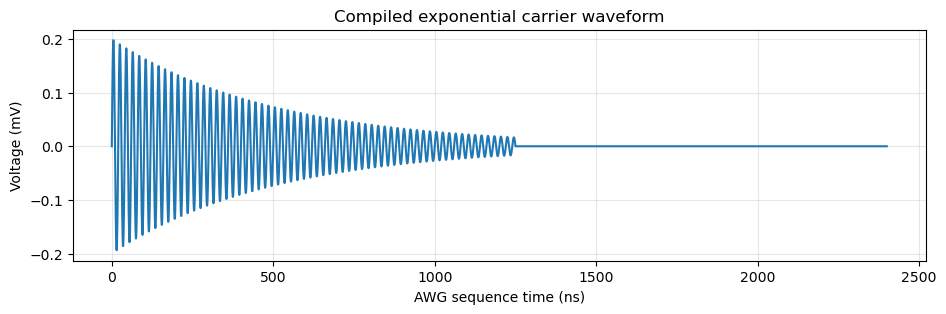

Sequence: TomographyProgram
Pulse style: exponential
Simulated emission T1: 250 ns
AWG error: 0,"No error"


In [15]:
program = TomographyProgram(program_cfg)
compiled = program.compile(hardware=experiment)

preview = compiled.preview(AWG_SIGNAL_CHANNEL)[0]
preview_time_ns = np.arange(preview.size) / AWG_SAMPLE_RATE_HZ * 1e9
plt.figure(figsize=(11, 3))
plt.plot(preview_time_ns, preview * 1e3)
plt.xlabel("AWG sequence time (ns)")
plt.ylabel("Voltage (mV)")
plt.title(f"Compiled {PULSE_STYLE} carrier waveform")
plt.grid(True, alpha=0.3)
plt.show()

sequence_name = compiled.upload()
print("Sequence:", sequence_name)
print("Pulse style:", PULSE_STYLE)
if PULSE_STYLE == "exponential":
    print("Simulated emission T1:", EMISSION_T1_NS, "ns")
print("AWG error:", experiment.awg.error())

## Acquire reference and signal shots

In [16]:
# Reference: keep the marker running, disable only the analog carrier output.
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, False)
reference_result = compiled.acquire(NUM_REFERENCE_SHOTS)
reference_records = reference_result.raw[:, 0, :]

# Signal: same waveform and marker timing, analog carrier enabled.
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, True)
signal_result = compiled.acquire(NUM_SIGNAL_SHOTS)
signal_records = signal_result.raw[:, 0, :]

# Tomography starts from unaveraged records and demodulates every shot.
reference_baseband = digital_downconvert(
    reference_records,
    ALAZAR_SAMPLE_RATE_HZ,
    FC_HZ,
)
signal_baseband = digital_downconvert(
    signal_records,
    ALAZAR_SAMPLE_RATE_HZ,
    FC_HZ,
)

# Suppress the real-signal 2*fc image before temporal-mode projection.
processor = AlazarProcessor(ALAZAR_SAMPLE_RATE_HZ)
LOWPASS_CUTOFF_HZ = min(20e6, 0.4 * FC_HZ)
reference_baseband = processor.apply_butterworth_lpf(
    reference_baseband,
    cutoff_hz=LOWPASS_CUTOFF_HZ,
)
signal_baseband = processor.apply_butterworth_lpf(
    signal_baseband,
    cutoff_hz=LOWPASS_CUTOFF_HZ,
)

print("Reference baseband:", reference_baseband.shape)
print("Signal baseband:", signal_baseband.shape)
print("Signal capture diagnostics:")
for key, value in experiment.capture_diagnostics().items():
    print(f"  {key}: {value}")

Reference baseband: (5000, 1408)
Signal baseband: (5000, 1408)
Signal capture diagnostics:
  adc_channel: CHB
  adc_bits: 12
  adc_lsb_mv: 0.1953125
  raw_code_min: 32592
  raw_code_max: 33008
  mean_offset_mv: 0.5317921031605117
  average_peak_to_peak_mv: 0.44023437499998663
  shot_noise_std_mv: 0.5541856101531926


## Inspect raw and coherently averaged records

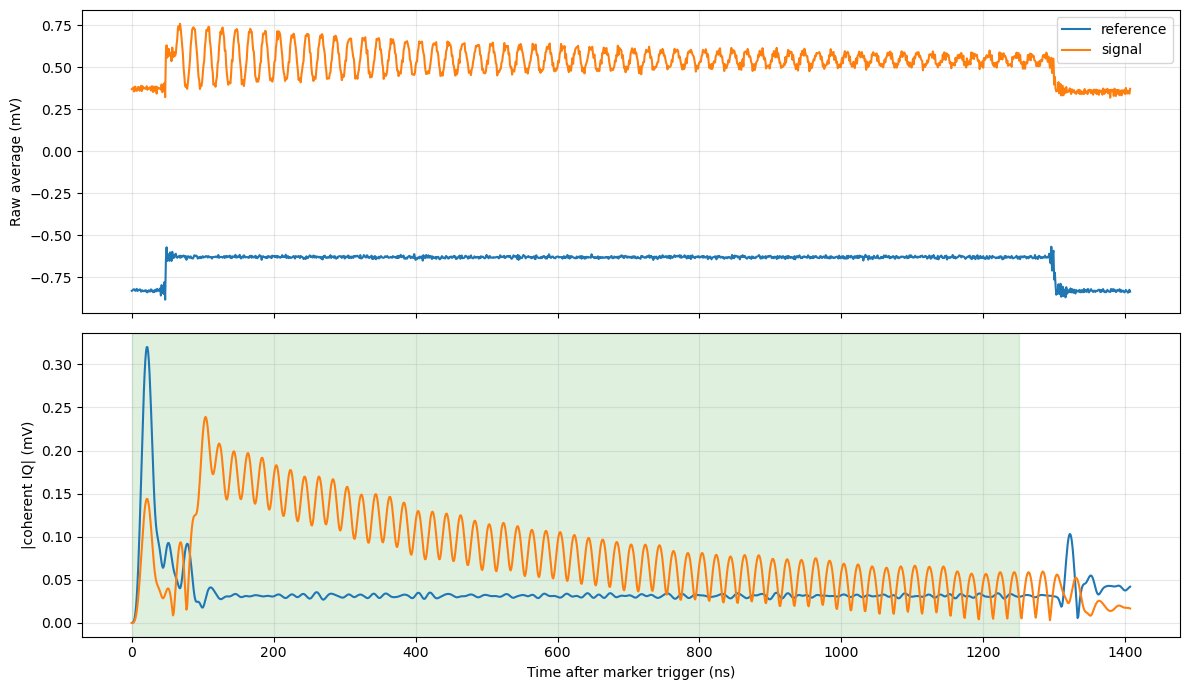

In [17]:
time_ns = np.arange(signal_records.shape[1]) / ALAZAR_SAMPLE_RATE_HZ * 1e9

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(time_ns, np.mean(reference_records, axis=0) * 1e3, label="reference")
axes[0].plot(time_ns, np.mean(signal_records, axis=0) * 1e3, label="signal")
axes[0].set_ylabel("Raw average (mV)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_ns, np.abs(np.mean(reference_baseband, axis=0)) * 1e3)
axes[1].plot(time_ns, np.abs(np.mean(signal_baseband, axis=0)) * 1e3)
axes[1].axvspan(MODE_START_NS, MODE_STOP_NS, color="tab:green", alpha=0.15)
axes[1].set_xlabel("Time after marker trigger (ns)")
axes[1].set_ylabel("|coherent IQ| (mV)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temporal-mode projection

In [18]:
mode_start = experiment.ns2cycles(MODE_START_NS, inst="adc")
mode_stop = experiment.ns2cycles(MODE_STOP_NS, inst="adc")
mode_samples = mode_stop - mode_start
sigma_samples = GAUSSIAN_SIGMA_NS * 1e-9 * ALAZAR_SAMPLE_RATE_HZ
decay_samples = EMISSION_T1_NS * 1e-9 * ALAZAR_SAMPLE_RATE_HZ

mode = temporal_mode_weights(
    mode_samples,
    kind=MODE_KIND,
    sigma_samples=sigma_samples if MODE_KIND == "gaussian" else None,
    decay_samples=decay_samples if MODE_KIND == "exponential" else None,
)
reference_mode_volts = project_temporal_mode(
    reference_baseband,
    mode,
    start_sample=mode_start,
)
signal_mode_volts = project_temporal_mode(
    signal_baseband,
    mode,
    start_sample=mode_start,
)

print("Reference mean:", np.mean(reference_mode_volts))
print("Signal mean:", np.mean(signal_mode_volts))
print("Electrical SNR:", abs(np.mean(signal_mode_volts) - np.mean(reference_mode_volts))
      / np.std(reference_mode_volts))

Reference mean: (-0.00010506675293935027+0.00037867016793873817j)
Signal mean: (-0.0016531824946060638-0.0022734777219900848j)
Electrical SNR: 4.082363666849501


## Reference normalization

The reference is centered and scaled so
\(\langle |\alpha|^2\rangle_{\rm ref}=1\), matching the ideal vacuum
heterodyne convention. At room temperature this is a convenient numerical
normalization only. For quantum tomography, replace it with a calibrated
system gain/noise measurement.

IQ offset (mode volts): (-0.00010506675293935027+0.00037867016793873817j)
IQ scale (mode volts / alpha): 0.0007522407201127842
Reference <|alpha|^2>: 1.0
Signal mean alpha: (-2.0580057689971945-3.525663818798833j)
Reference quadrature variances: 0.5058031345160343 0.49419686548396574


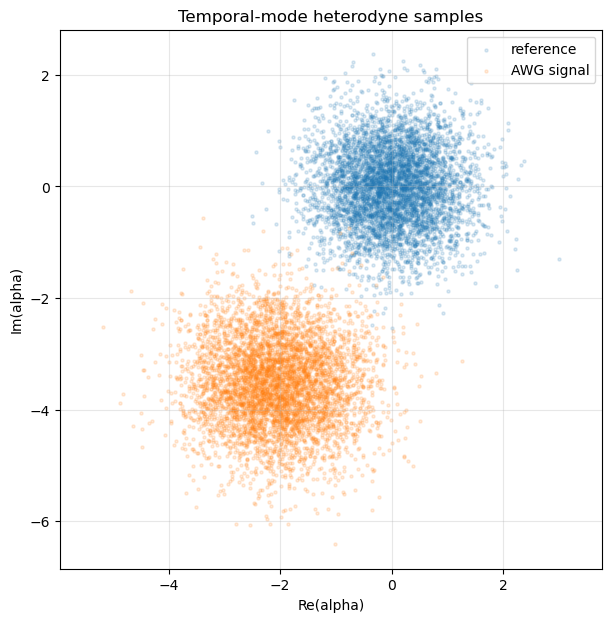

In [19]:
alpha_reference, (alpha_signal,), iq_offset, iq_scale = (
    normalize_heterodyne_reference(reference_mode_volts, signal_mode_volts)
)

print("IQ offset (mode volts):", iq_offset)
print("IQ scale (mode volts / alpha):", iq_scale)
print("Reference <|alpha|^2>:", np.mean(np.abs(alpha_reference) ** 2))
print("Signal mean alpha:", np.mean(alpha_signal))
print("Reference quadrature variances:",
      np.var(alpha_reference.real), np.var(alpha_reference.imag))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(alpha_reference.real, alpha_reference.imag, s=5, alpha=0.15, label="reference")
ax.scatter(alpha_signal.real, alpha_signal.imag, s=5, alpha=0.15, label="AWG signal")
ax.set_xlabel("Re(alpha)")
ax.set_ylabel("Im(alpha)")
ax.set_title("Temporal-mode heterodyne samples")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Maximum-likelihood density matrix

trace(rho): (1+0j)
minimum eigenvalue: 2.783060611957261e-12
purity: 0.999999999832605
overlap with coherent state at mean alpha: 0.9999664897226442
photon populations: [1.14923326e-05 1.42645366e-04 1.11476801e-03 6.25801288e-03
 2.68205538e-02 9.15649064e-02 2.57874174e-01 6.16213447e-01]
mean photon number <n>: 6.446992141662124
g2(0): 0.861571654510361
population at Fock cutoff: 0.6162134470305708


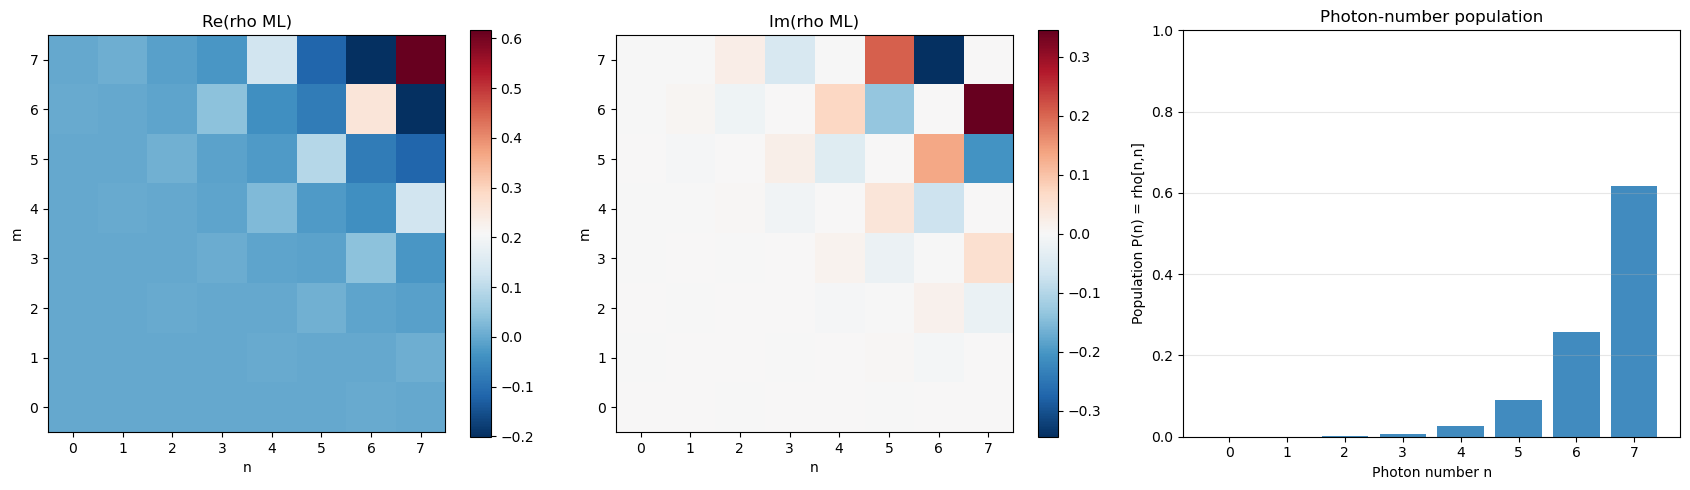

In [20]:
rho_ml = heterodyne_ml_density_matrix(
    alpha_signal,
    cutoff=FOCK_CUTOFF,
    iterations=ML_ITERATIONS,
    dilution=0.5,
)
alpha_mean = np.mean(alpha_signal)
rho_coherent = coherent_density_matrix(alpha_mean, cutoff=FOCK_CUTOFF)
fidelity_to_coherent = float(np.real(np.trace(rho_ml @ rho_coherent)))
purity = float(np.real(np.trace(rho_ml @ rho_ml)))

print("trace(rho):", np.trace(rho_ml))
print("minimum eigenvalue:", np.min(np.linalg.eigvalsh(rho_ml)))
print("purity:", purity)
print("overlap with coherent state at mean alpha:", fidelity_to_coherent)
photon_population = np.maximum(np.real(np.diag(rho_ml)), 0.0)
photon_population /= np.sum(photon_population)
photon_number = np.arange(FOCK_CUTOFF)
mean_photon_number = float(np.sum(photon_number * photon_population))
factorial_moment_2 = float(
    np.sum(photon_number * (photon_number - 1) * photon_population)
)
g2_zero = (
    factorial_moment_2 / mean_photon_number**2
    if mean_photon_number > 0
    else np.nan
)

print("photon populations:", photon_population)
print("mean photon number <n>:", mean_photon_number)
print("g2(0):", g2_zero)
print("population at Fock cutoff:", photon_population[-1])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
image0 = axes[0].imshow(np.real(rho_ml), origin="lower", cmap="RdBu_r")
axes[0].set_title("Re(rho ML)")
axes[0].set_xlabel("n")
axes[0].set_ylabel("m")
plt.colorbar(image0, ax=axes[0])
image1 = axes[1].imshow(np.imag(rho_ml), origin="lower", cmap="RdBu_r")
axes[1].set_title("Im(rho ML)")
axes[1].set_xlabel("n")
axes[1].set_ylabel("m")
plt.colorbar(image1, ax=axes[1])

axes[2].bar(photon_number, photon_population, color="tab:blue", alpha=0.85)
axes[2].set_xticks(photon_number)
axes[2].set_ylim(0, max(1.0, 1.1 * np.max(photon_population)))
axes[2].set_xlabel("Photon number n")
axes[2].set_ylabel("Population P(n) = rho[n,n]")
axes[2].set_title("Photon-number population")
axes[2].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

if photon_population[-1] > 0.01:
    print(
        "WARNING: population at the highest retained Fock state exceeds 1%. "
        "Increase FOCK_CUTOFF before trusting the reconstruction."
    )

## Wigner function calculated from the reconstructed density matrix

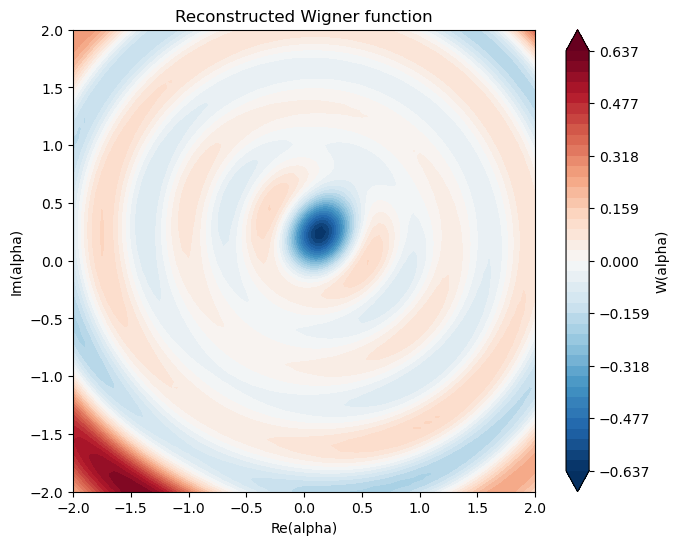

Wigner minimum: -0.6306640645113216
Wigner integral estimate: 0.03179343520895476
Interpret only the central region. Rings near the plot boundary can be finite-Fock-cutoff artifacts rather than physical photon populations.


In [21]:
axis = np.linspace(-WIGNER_LIMIT, WIGNER_LIMIT, WIGNER_POINTS)
wigner = wigner_function(rho_ml, axis, axis)

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.linspace(-2 / np.pi, 2 / np.pi, 41)
contour = ax.contourf(axis, axis, wigner, levels=levels, cmap="RdBu_r", extend="both")
ax.set_xlabel("Re(alpha)")
ax.set_ylabel("Im(alpha)")
ax.set_title("Reconstructed Wigner function")
ax.set_aspect("equal")
plt.colorbar(contour, ax=ax, label="W(alpha)")
plt.show()

print("Wigner minimum:", np.min(wigner))
print("Wigner integral estimate:",
      np.sum(wigner) * (axis[1] - axis[0]) ** 2)
print(
    "Interpret only the central region. Rings near the plot boundary can be "
    "finite-Fock-cutoff artifacts rather than physical photon populations."
)

## Save acquisition and reconstruction

In [ ]:
np.savez_compressed(
    "tomography_capture.npz",
    reference_records=reference_records,
    signal_records=signal_records,
    reference_mode_volts=reference_mode_volts,
    signal_mode_volts=signal_mode_volts,
    alpha_reference=alpha_reference,
    alpha_signal=alpha_signal,
    temporal_mode=mode,
    density_matrix=rho_ml,
    wigner_axis=axis,
    wigner=wigner,
    fc_hz=FC_HZ,
    sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
)
print("Saved tomography_capture.npz")

## Close hardware session

In [ ]:
experiment.awg.set_output(AWG_SIGNAL_CHANNEL, False)
experiment.close()
print("AWG VISA session closed")